# CosmX Pancreas Evaluation

In [ ]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd


import InterScale as interscale
from InterScale.config import load_config
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
#from InterScale.eval.gene_rank_analysis import predict_gene_r2, gene_rank_analysis
from InterScale.tl import prepare_a2d_dataset
from InterScale.evaluation import scale_cls_by_sample

from pathlib import Path
import torch

In [8]:
CFG_CLASS = "/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/config_files/Cosmx_pancreas/clas_graph.yaml"
RESULTS_DIR = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/melton25/"

## Load pretrained models

In [3]:
cfg = load_config(CFG_CLASS)

In [4]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v'
    obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_fov'
    layers: 'counts'

In [5]:
adata.obsm['spatial']

array([[ 832, 3627],
       [1211, 3625],
       [1499, 3602],
       ...,
       [ 184,   17],
       [ 237,   16],
       [ 812,   17]])

In [6]:
# import torch

# model = torch.load('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/results/cosmx_pancreas/pancreas_regr_node_GCN__model.pt')
# state_dict = model['state_dict']

Want to load from: '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/melton25/melton25_clas_graph_44_GCN_self-attn-transformer_model.ckpt'

In [9]:
#interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
#local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False, wandb_save = True)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True, wandb_save = True)

/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


WeightedCE with class weights:  tensor([1.1977, 0.8583], dtype=torch.float64)
Loading model from /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/melton25/melton25_clas_graph_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/dss/dsshome1/05/di93tig/1_projects/GT-long-range-niches/src/InterScale/model/base/_base_model.py:579: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the u

In [9]:
combined_model

## Inference 

In [10]:
result_t1d = combined_model.get_model_output(adata[adata.obs['condition'] == 'T1D'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .X
call new
{'condition': ['T1D']}


In [11]:
result_nd = combined_model.get_model_output(adata[adata.obs['condition'] == 'ND'], prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    


/usr/local/lib/python3.10/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Load GEX from .X
call new
{'condition': ['ND']}


In [12]:
result_nd.obsm['combined_y_pred']

array([[-1.04037344455719, 1.8209331035614014],
       [-1.04037344455719, 1.8209331035614014],
       [-1.04037344455719, 1.8209331035614014],
       ...,
       [-0.555424153804779, 1.424800157546997],
       [-0.5095838308334351, 0.9009404182434082],
       [-0.555424153804779, 1.424800157546997]], dtype=object)

In [13]:
result_nd

AnnData object with n_obs × n_vars = 161439 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_prediction_obs', '_scvi_group_key', 'combined_cls_horizontal', 'combined_cls_vertical'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'one_hot_mappings'
    o

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

## Evaluation score

In [34]:
from InterScale.evaluation import calculate_pr_auc

In [35]:
calculate_pr_auc(result_t1d)

IndexError: list index out of range

In [21]:
result_nd

AnnData object with n_obs × n_vars = 161439 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'slide_fov', 'slide_condition', 'split', 'split_0', 'split_1', 'split_2', 'globalX', 'globalY', 'sliding_window_square', 'sliding_window_h', 'sliding_window_v', '_scvi_sample_key_0', '_scvi_prediction_obs', '_scvi_group_key', 'combined_cls_horizontal', 'combined_cls_vertical', 'combined_cls_horizontal_scaled', 'combined_cls_vertical_scaled'
   

## Graph Label analysis

First, we scale the CLS token and then calculate the average mean expression of the CLS (horizontal and vertical) token per cell type.

In [ ]:
from InterScale.evaluation.graph_classification import scale_cls_by_sample
scale_cls_by_sample(result_nd, "slide_fov")
scale_cls_by_sample(result_t1d, "slide_fov")

/tmp/ipykernel_222033/2744131737.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = result_t1d.obs.groupby('cell_type_coarse').agg(


<AxesSubplot: ylabel='cell_type_coarse'>

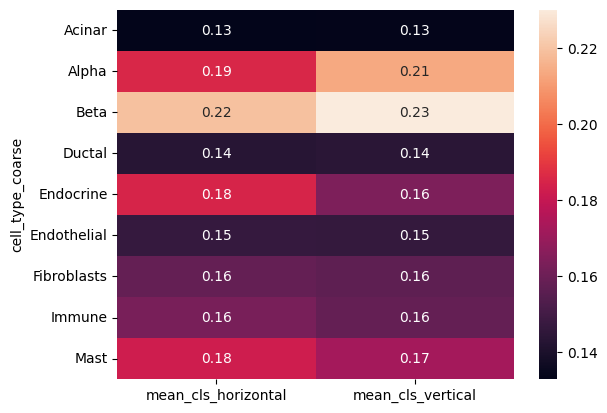

In [29]:
data = result_t1d.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)
sns.heatmap(data, annot=True)

/tmp/ipykernel_222033/2808000157.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = result_nd.obs.groupby('cell_type_coarse').agg(


<AxesSubplot: ylabel='cell_type_coarse'>

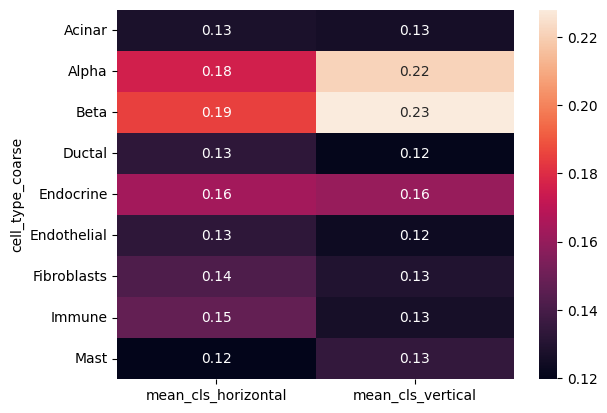

In [30]:
import seaborn as sns

data = result_nd.obs.groupby('cell_type_coarse').agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)
sns.heatmap(data, annot=True)

In [ ]:
canpy.pl.heatmap(result_nd, var_names, groupby,

In [34]:
np.unique(result_t1d[result_t1d.obs['split'] == 'test'].obs['slide_fov'])

array(['3_1', '3_10', '3_11', '3_12', '3_13', '3_14', '3_2', '3_25',
       '3_3', '3_4', '3_5', '3_6', '3_7', '3_8', '3_9'], dtype=object)

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


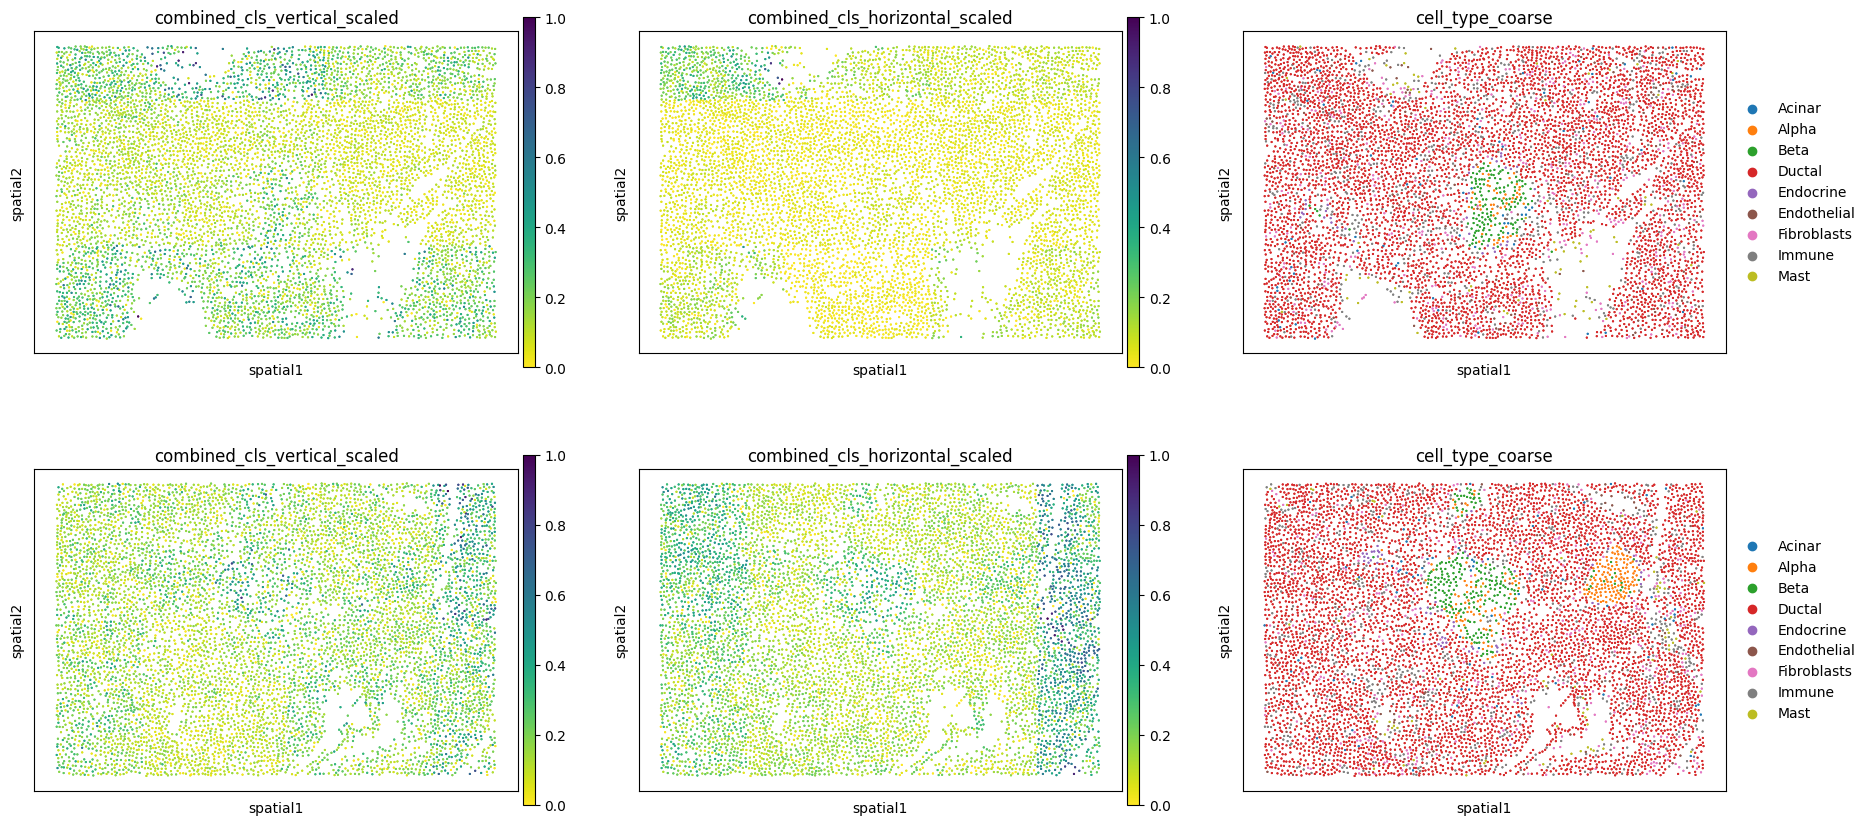

In [36]:
sq.pl.spatial_scatter(result_t1d[result_t1d.obs['split'] == 'test'], 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'cell_type_coarse'],
                      library_key = 'slide_fov',
                      library_id = ['3_12', '3_13'],
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 3,
)

In [35]:
np.unique(result_nd[result_nd.obs['split'] == 'test'].obs['slide_fov'])

array(['3_15', '3_16', '3_17', '3_18', '3_19', '3_20', '3_21', '3_22',
       '3_23', '3_24'], dtype=object)

/dss/dsshome1/05/di93tig/.local/lib/python3.10/site-packages/scanpy/plotting/_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.10/dist-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


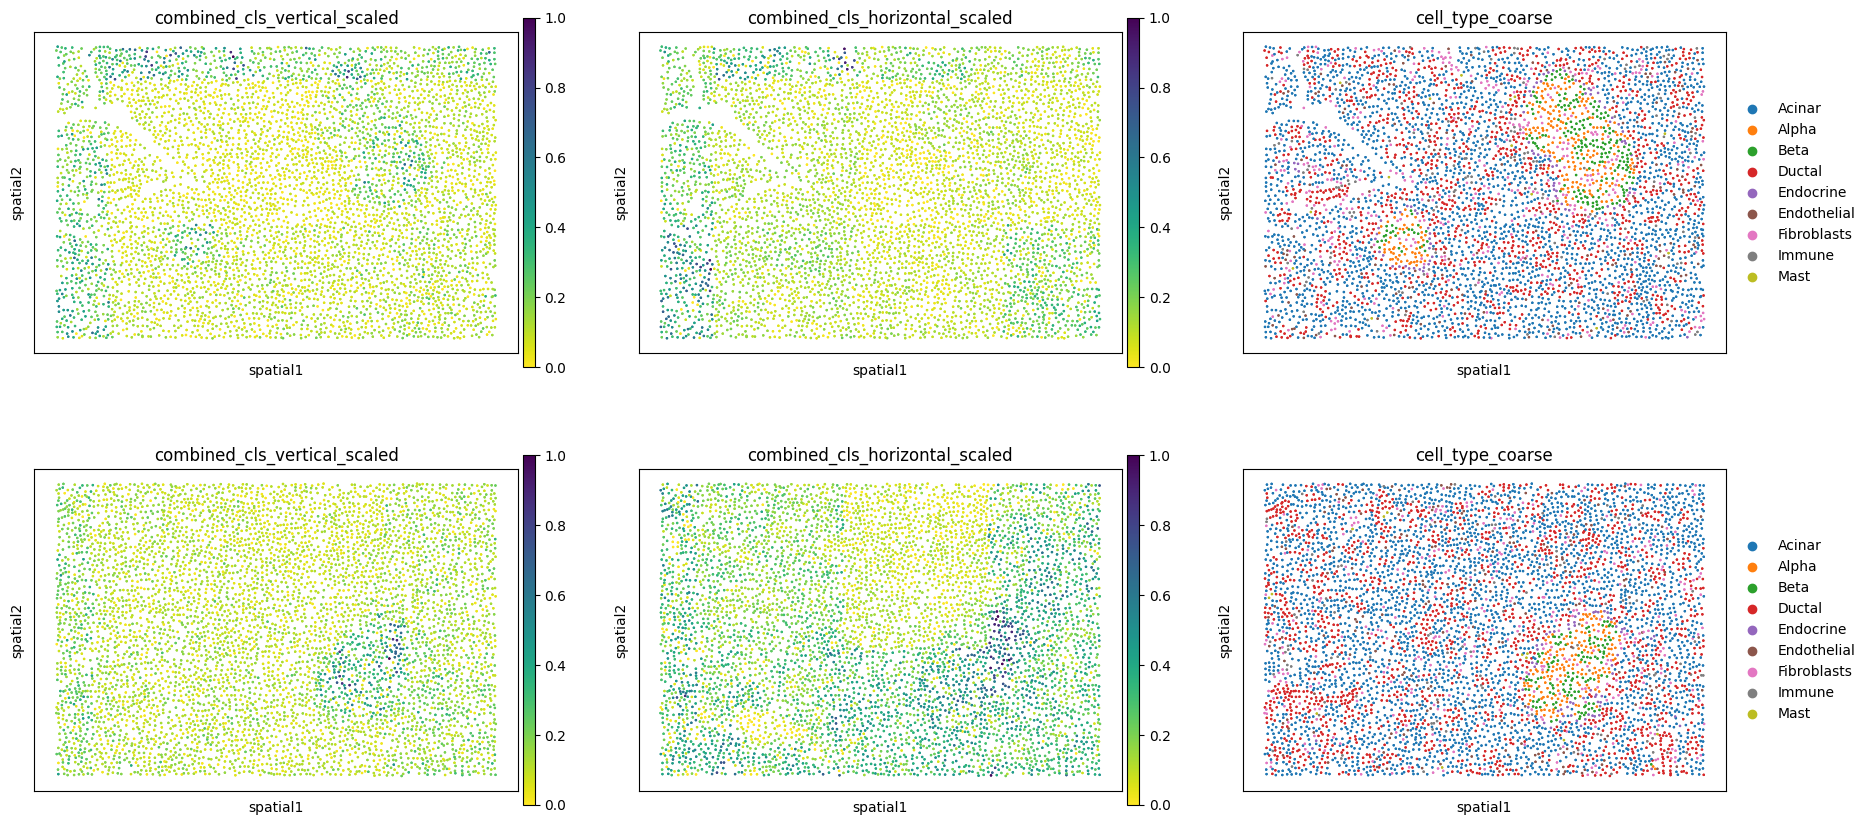

In [38]:
sq.pl.spatial_scatter(result_nd[result_nd.obs['split'] == 'test'], 
                      color =  ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled', 'cell_type_coarse'],
                      library_key = 'slide_fov',
                      library_id = ['3_15', '3_17'],
                    cmap = 'viridis_r',
                    shape= None,
                      ncols = 3,
)